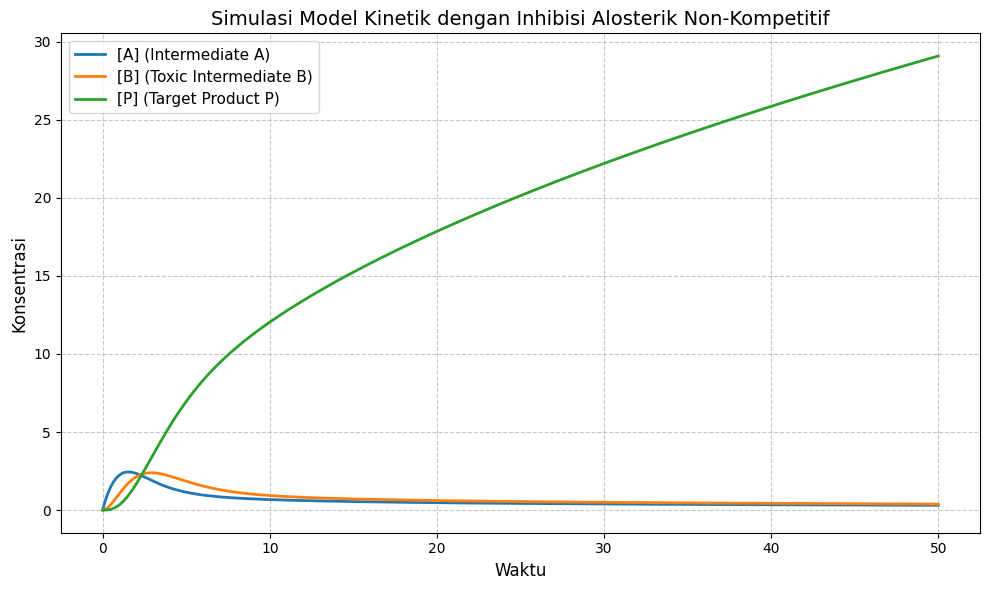

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# --- 1. Definisi Parameter ---
V1_max = 5.0
Km1 = 2.0
Ki = 3.0
X = 10.0
k2 = 1.0
k3 = 0.8
k4 = 0.3

# --- 2. Definisi Sistem Persamaan Diferensial (ODE) ---
def metabolic_model(t, y):
    # Unpack variabel terikat: A, B, P
    A, B, P = y

    # Persamaan laju reaksi berdasarkan model inhibisi non-kompetitif
    v1 = (V1_max * X) / ((Km1 + X) * (1 + (P / Ki)))
    v2 = k2 * A
    v3 = k3 * B
    v4 = k4 * A

    # Persamaan diferensial perubahan konsentrasi (Q2B)
    dA_dt = v1 - v2 - v4
    dB_dt = v2 - v3
    dP_dt = v3

    return [dA_dt, dB_dt, dP_dt]

# --- 3. Kondisi Awal dan Rentang Waktu ---
y0 = [0.0, 0.0, 0.0] # Konsentrasi awal [A], [B], [P]
t_span = (0, 50)     # Rentang waktu simulasi (misal: 0 sampai 50 satuan waktu)
t_eval = np.linspace(t_span[0], t_span[1], 500) # Titik evaluasi agar kurva halus

# --- 4. Menyelesaikan ODE ---
# Menggunakan metode Runge-Kutta orde 4(5) yang merupakan standar di solve_ivp
sol = solve_ivp(metabolic_model, t_span, y0, t_eval=t_eval, method='RK45')

# --- 5. Visualisasi Hasil ---
plt.figure(figsize=(10, 6))
plt.plot(sol.t, sol.y[0], label='[A] (Intermediate A)', linewidth=2)
plt.plot(sol.t, sol.y[1], label='[B] (Toxic Intermediate B)', linewidth=2)
plt.plot(sol.t, sol.y[2], label='[P] (Target Product P)', linewidth=2)

plt.title('Simulasi Model Kinetik dengan Inhibisi Alosterik Non-Kompetitif', fontsize=14)
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Konsentrasi', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Tampilkan plot grafik
plt.show()